# Cauchy Residual Mixer vs Standard Residual on a Challenging Function

目标函数：
$$z(x) = \sin(x)\cos(y) + 0.1\sin(5x)\cos(5y) + \sin(x^2 + y^2)$$

实验设置：
- 30 层 MLP（输入 2 维，输出 1 维）
- 对比标准残差与 Cauchy-Mixer
- 绘制拟合曲线与损失下降曲线
- 和 numpy 计算得到的真值做误差比较

In [1]:
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

sys.path.append(os.path.abspath("../../src"))
from cauchy_res_mixer.model import CauchyResidualMLP

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


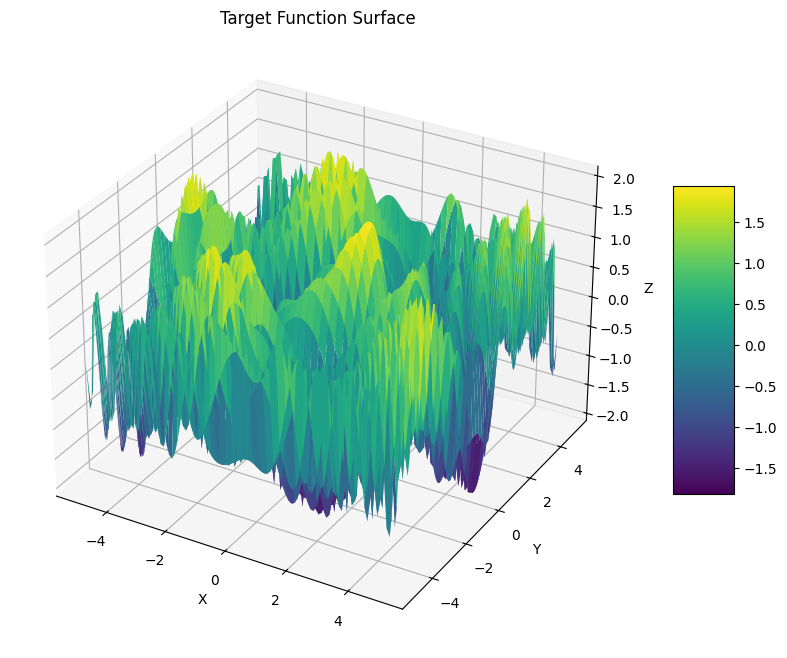

In [2]:
def target_numpy(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    # sin(x)cos(y) + 0.1sin(5x)cos(5y) + sin(x^2 + y^2)
    return (
        np.sin(x) * np.cos(y)
        + 0.1 * np.sin(5 * x) * np.cos(5 * y)
        + np.sin(x**2 + y**2)
    )


X = np.linspace(-5, 5, 100)
Y = np.linspace(-5, 5, 100)
X_grid, Y_grid = np.meshgrid(X, Y)
Z_grid = target_numpy(X_grid, Y_grid)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X_grid, Y_grid, Z_grid, cmap="viridis")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Target Function Surface")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()


In [3]:
# 生成训练数据
n_samples = 5000
x = np.random.uniform(-3.0, 3.0, size=(n_samples, 1)).astype(np.float32)
y = np.random.uniform(-3.0, 3.0, size=(n_samples, 1)).astype(np.float32)
z = target_numpy(x, y).astype(np.float32)

x_train, x_test, y_train, y_test, z_train, z_test = train_test_split(
    x, y, z, test_size=0.2, random_state=random_seed
)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
z_train_t = torch.tensor(z_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
z_test_t = torch.tensor(z_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train_t, y_train_t, z_train_t), batch_size=128, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(x_test_t, y_test_t, z_test_t), batch_size=256, shuffle=False
)

x_train_t.shape, y_train_t.shape, z_train_t.shape, len(train_loader), len(test_loader)

(torch.Size([4000, 1]), torch.Size([4000, 1]), torch.Size([4000, 1]), 32, 4)

In [4]:
from tqdm import tqdm


def train_model(
    residual_mode: str,
    epochs: int = 1,
    lr: float = 1e-3,
    activation_mode: str = "cauchy",
):
    model = CauchyResidualMLP(
        input_dim=2,
        hidden_dim=128,
        num_classes=1,
        num_layers=30,
        residual_mode=residual_mode,
        activation_mode=activation_mode,
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    train_losses = []
    val_losses = []

    pbar = tqdm(
        range(epochs),
        desc=f"Training {residual_mode} - {activation_mode}",
    )

    for _ in pbar:
        model.train()
        running_train = 0.0
        count_train = 0

        for xb, yb, zb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            zb = zb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(torch.cat([xb, yb], dim=1))
            loss = criterion(pred, zb)
            loss.backward()
            optimizer.step()

            running_train += float(loss.item()) * xb.size(0)
            count_train += xb.size(0)

        epoch_train_loss = running_train / max(count_train, 1)

        model.eval()
        running_val = 0.0
        count_val = 0
        with torch.no_grad():
            for xb, yb, zb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                zb = zb.to(device)
                pred = model(torch.cat([xb, yb], dim=1))
                val_loss = criterion(pred, zb)

                running_val += float(val_loss.item()) * xb.size(0)
                count_val += xb.size(0)

        epoch_val_loss = running_val / max(count_val, 1)
        pbar.set_postfix_str(
            f"train_loss: {epoch_train_loss:.4f}, val_loss: {epoch_val_loss:.4f}"
        )

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

    return model, train_losses, val_losses

Training standard - relu: 100%|██████████| 300/300 [06:48<00:00,  1.36s/it, train_loss: 0.0009, val_loss: 0.0008]


Final Losses:
Cauchy Residuals (Cauchy Activation): train=0.0009050869191996753, val=0.0006381274648010731
Standard Residuals (Cauchy Activation): train=0.0022313305344432593, val=0.002479140231385827
Cauchy Residuals (ReLU Activation): train=0.0032262878566980363, val=0.0031126783248037098
Standard Residuals (ReLU Activation): train=0.0009388761986047029, val=0.0008080315710976719


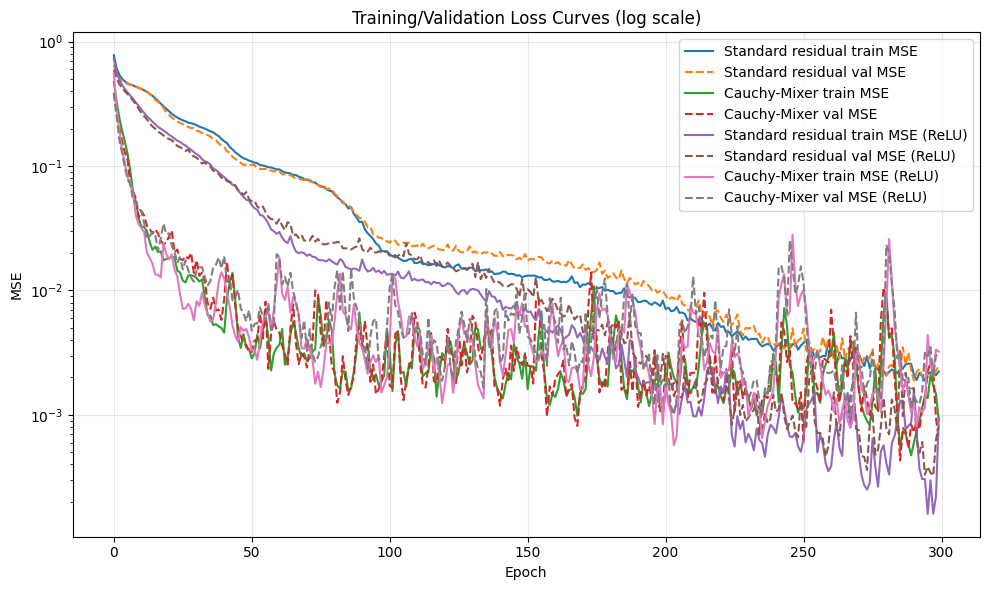

In [5]:
epochs = 300
lr = 1e-5
model_cauchy, loss_cauchy_train, loss_cauchy_val = train_model(
    residual_mode="cauchy",
    epochs=epochs,
    lr=lr,
    activation_mode="cauchy",
)
model_standard, loss_standard_train, loss_standard_val = train_model(
    residual_mode="standard",
    epochs=epochs,
    lr=lr,
    activation_mode="cauchy",
)
model_cauchy_relu, loss_cauchy_relu_train, loss_cauchy_relu_val = train_model(
    residual_mode="cauchy",
    epochs=epochs,
    lr=lr,
    activation_mode="relu",
)
model_relu, loss_relu_train, loss_relu_val = train_model(
    residual_mode="standard",
    epochs=epochs,
    lr=lr,
    activation_mode="relu",
)

print("Final Losses:")
print(
    f"Cauchy Residuals (Cauchy Activation): train={loss_cauchy_train[-1]}, val={loss_cauchy_val[-1]}"
)
print(
    f"Standard Residuals (Cauchy Activation): train={loss_standard_train[-1]}, val={loss_standard_val[-1]}"
)
print(
    f"Cauchy Residuals (ReLU Activation): train={loss_cauchy_relu_train[-1]}, val={loss_cauchy_relu_val[-1]}"
)
print(
    f"Standard Residuals (ReLU Activation): train={loss_relu_train[-1]}, val={loss_relu_val[-1]}"
)

plt.figure(figsize=(10, 6))
plt.plot(loss_standard_train, label="Standard residual train MSE")
plt.plot(loss_standard_val, "--", label="Standard residual val MSE")
plt.plot(loss_cauchy_train, label="Cauchy-Mixer train MSE")
plt.plot(loss_cauchy_val, "--", label="Cauchy-Mixer val MSE")
plt.plot(loss_relu_train, label="Standard residual train MSE (ReLU)")
plt.plot(loss_relu_val, "--", label="Standard residual val MSE (ReLU)")
plt.plot(loss_cauchy_relu_train, label="Cauchy-Mixer train MSE (ReLU)")
plt.plot(loss_cauchy_relu_val, "--", label="Cauchy-Mixer val MSE (ReLU)")
plt.yscale("log")
plt.title("Training/Validation Loss Curves (log scale)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

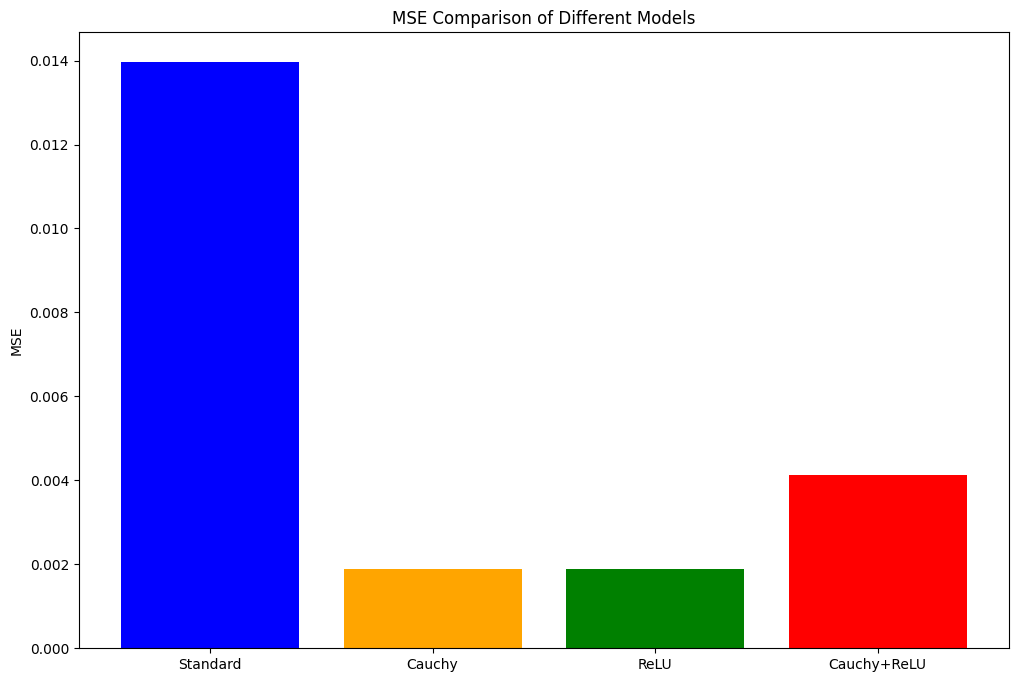

Comparison to Numpy truth on dense grid:
Standard residual MLP MSE:        0.013975
Cauchy-Mixer MLP MSE:             0.001883
Standard residual MLP (ReLU) MSE: 0.001896
Cauchy-Mixer MLP (ReLU) MSE:      0.004122


In [6]:
x_grid = np.linspace(-3.0, 3.0, 1200, dtype=np.float32).reshape(-1, 1)
y_grid = np.linspace(-3.0, 3.0, 1200, dtype=np.float32).reshape(-1, 1)
z_np = target_numpy(x_grid, y_grid).reshape(-1, 1)
x_grid_t = torch.tensor(x_grid, dtype=torch.float32, device=device)
y_grid_t = torch.tensor(y_grid, dtype=torch.float32, device=device)
xy_tensor = torch.cat([x_grid_t, y_grid_t], dim=1)

with torch.no_grad():
    z_pred_standard = model_standard(xy_tensor).cpu().numpy()
    z_pred_cauchy = model_cauchy(xy_tensor).cpu().numpy()
    z_pred_relu = model_relu(xy_tensor).cpu().numpy()
    z_pred_cauchy_relu = model_cauchy_relu(xy_tensor).cpu().numpy()

mse_standard_np = float(np.mean((z_pred_standard - z_np) ** 2))
mse_cauchy_np = float(np.mean((z_pred_cauchy - z_np) ** 2))
mse_relu_np = float(np.mean((z_pred_relu - z_np) ** 2))
mse_cauchy_relu_np = float(np.mean((z_pred_cauchy_relu - z_np) ** 2))


plt.figure(figsize=(12, 8))
plt.bar(
    ["Standard", "Cauchy", "ReLU", "Cauchy+ReLU"],
    [mse_standard_np, mse_cauchy_np, mse_relu_np, mse_cauchy_relu_np],
    color=["blue", "orange", "green", "red"],
)
plt.ylabel("MSE")
plt.title("MSE Comparison of Different Models")
plt.show()
print("Comparison to Numpy truth on dense grid:")
print(f"Standard residual MLP MSE:        {mse_standard_np:.6f}")
print(f"Cauchy-Mixer MLP MSE:             {mse_cauchy_np:.6f}")
print(f"Standard residual MLP (ReLU) MSE: {mse_relu_np:.6f}")
print(f"Cauchy-Mixer MLP (ReLU) MSE:      {mse_cauchy_relu_np:.6f}")